# BTST Lagrangian Portfolio Strategy ('1lg0') — Backtest & Live Signals

Ported from `traderealm` (`nse_order_creation.py` + `backtest/runner.py` + `strategy/utils.py`).
This is the BTST strategy that ran live in 2023.

**How it works**
- Every trading day near the close, take the last `lb` trading days of **close→open** returns for every ticker in the universe.
- Maximise a Sharpe-like Lagrangian objective (`(mean - rf) / vol + 0.05·‖w‖²` penalty) with SLSQP under long-only bounds `0 ≤ w ≤ 0.5`, `Σw = 1`.
- Keep only the top `trades` weights, re-normalise to 1.
- **Buy each selected name at the close** with `perc · tot_capital / (lf+1)` (rolling capital tranches).
- Sell at the next open; the still-pending net book is re-bought at close daily, so exposure is **overnight-only for `lf` consecutive nights**.

**Live 2023 config** (from `btst_strategy_v2.ipynb`, universe `1.4`): `lb=20, trades=5, lf=5, tot_capital=10L`.
The later research config (`btst_strategy.ipynb`, 2024-25) used `trades=15, lf=15` on a larger universe.

Data comes from the Fyers daily cache (`data/fyers_spot_daily`), fetched with this repo's own scripts — no traderealm DB needed.
Note: traderealm resampled minute bars to a 09:20–15:20 session, so its "Close" was the 15:20 price; here we use official daily OHLC (15:30 close), a small difference.

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("load_ext", "autoreload")
    except Exception:
        pass
    ip.run_line_magic("autoreload", "2")

from intraday_research.fyers_cache import safe_symbol_filename
from intraday_research.btst_lagrangian import (
    backtest_daily,
    generate_live_signals,
    get_trade_statistics,
    run_backtest,
    session_daily_from_minute,
)
from intraday_research.btst_sweeps import run_sweep
from intraday_research.universe import load_universe

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
# Default: nifty50 universe (daily data mostly cached already).
# For the full traderealm 2024HY1 top-500 universe use btst_universe.json and
# slice the first TOP_N symbols (equivalent of the old tick_len param).
UNIVERSE_FILE = REPO_ROOT / "research_universe.example.json"
# UNIVERSE_FILE = REPO_ROOT / "btst_universe.json"
TOP_N = 250  # e.g. 250 to use only the first N symbols of the universe

CACHE_DATA_DIR = REPO_ROOT / "data" / "fyers_spot_daily"
MINUTE_DATA_DIR = REPO_ROOT / "data" / "fyers"

# ── Price capture times ──────────────────────────────────────────────────────
# The strategy enters near market close and exits shortly after the next open.
# traderealm live captured the 15:20 price (session 09:20-15:20), not the
# official 15:30 close / 09:15 open. Requires 1-minute data (data/fyers).
USE_MINUTE_SESSION_PRICES = True
ENTRY_PRICE_TIME = "15:20"   # entry/signal price = traded price at this time (e.g. "15:20", "15:25")
EXIT_PRICE_TIME = "09:20"    # exit price = traded price at this time (e.g. "09:20", "09:25")
AUTH_FILE = REPO_ROOT / "fyers_auth.json"
USER_KEY = "user1"
FETCH_MISSING_SPOT_DATA = True
REFRESH_AUTH_BEFORE_FETCH = False

START_DATE = "2023-01-01"   # the backtest starts EXACTLY here for every variant
END_DATE = "2026-07-17"

# Data is loaded WARMUP_TRADING_DAYS before START_DATE so every lookback (lb)
# is already full on day one — all variants trade the same evaluation window.
# Keep it >= the largest lb you sweep (plus a few days).
WARMUP_TRADING_DAYS = 60
DATA_START_DATE = str((pd.Timestamp(START_DATE)
                       - pd.Timedelta(days=int(WARMUP_TRADING_DAYS * 1.7) + 10)).date())

PARAMS = {
    "strategy_id": "1lg0",
    "backtest_start": START_DATE,
    "return_type": "log",     # simple | log — 2023 live probably used log (traderealm's commented line)
    "cost_model": "day_netted",  # day_netted (same-day buy+sell = intraday, net residual = delivery) | per_leg (original)
    "frequency_type": "close to open",
    "tot_capital": 10_00_000,
    "lb": 30,
    "trades": 5,
    "lf": 3,
    "risk_free_rate": 0.02,
    "upper_bound": 0.5,
    "lower_bound": 0,
    "long_only": 1,
    "rmean": "sma",
    "objective": "sortino",  # lagrangian | sortino | calmar | mean_variance | cvar | omega | min_variance | combined
    "execution": "flat_legs",   # flat_legs (original live) | hold | delta | delta_close
}

universe = load_universe(UNIVERSE_FILE)
symbols = list(universe.symbols)
if TOP_N:
    symbols = symbols[:TOP_N] #[100:TOP_N]
print(f"universe: {universe.name} — {len(symbols)} symbols")

universe: btst_2024HY1_universe — 250 symbols


In [3]:
len(universe.symbols)

500

## Load Data

With `USE_MINUTE_SESSION_PRICES = True`, 1-minute candles (fetched into `data/fyers` if missing) are collapsed into session bars where **Close = traded price at `ENTRY_PRICE_TIME`** and **Open = traded price at `EXIT_PRICE_TIME`** — the prices the strategy actually executes at, exactly like traderealm's 09:20–15:20 session resampling. If the exact minute is missing on a day, the nearest candle inside the window is used.

With `False`, official daily OHLC bars are used instead (15:30 close / 09:15 open) from `data/fyers_spot_daily`.

In [4]:
def fetch_missing_data(fetch_symbols, resolution, output_dir):
    if not fetch_symbols:
        return
    command = [
        sys.executable,
        str(REPO_ROOT / "scripts" / "fetch_fyers_intraday_data.py"),
        "--auth-file", str(AUTH_FILE),
        "--user-key", USER_KEY,
        "--start", DATA_START_DATE,
        "--end", END_DATE,
        "--output-dir", str(output_dir),
        "--format", "parquet",
        "--resolution", resolution,
        "--chunk-days", "365" if resolution == "D" else "100",  # FYERS 1-min max range = 100 days/request
        "--skip-invalid-symbols",
    ]
    if REFRESH_AUTH_BEFORE_FETCH:
        command.append("--refresh-auth-before-fetch")
    for symbol in fetch_symbols:
        command.extend(["--symbol", symbol])
    result = subprocess.run(command, cwd=REPO_ROOT, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout[-3000:])
    if result.stderr:
        print(result.stderr[-2000:])
    if result.returncode != 0:
        raise RuntimeError(f"Data fetch failed with exit code {result.returncode}")


def plain_ticker(fyers_symbol):
    return fyers_symbol.removeprefix("NSE:").removesuffix("-EQ")


def load_symbol_daily(fyers_symbol):
    """Official daily OHLC bars (15:30 close / 09:15 open)."""
    path = CACHE_DATA_DIR / f"{safe_symbol_filename(fyers_symbol)}.parquet"
    if not path.exists():
        return None
    frame = pd.read_parquet(path)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"])
    frame["Date"] = frame["timestamp"].dt.date
    mask = (frame["Date"].astype(str) >= DATA_START_DATE) & (frame["Date"].astype(str) <= END_DATE)
    frame = frame.loc[mask]
    frame = frame.rename(columns={"open": "Open", "high": "High", "low": "Low",
                                  "close": "Close", "volume": "Volume"})
    return frame[["Date", "Open", "High", "Low", "Close", "Volume"]].sort_values("Date").reset_index(drop=True)


def load_symbol_session(fyers_symbol):
    """Session bars from 1-minute data: Close = price at ENTRY_PRICE_TIME,
    Open = price at EXIT_PRICE_TIME."""
    path = MINUTE_DATA_DIR / f"{safe_symbol_filename(fyers_symbol)}.parquet"
    if not path.exists():
        return None
    daily = session_daily_from_minute(pd.read_parquet(path),
                                      entry_price_time=ENTRY_PRICE_TIME,
                                      exit_price_time=EXIT_PRICE_TIME)
    mask = (daily["Date"].astype(str) >= DATA_START_DATE) & (daily["Date"].astype(str) <= END_DATE)
    return daily.loc[mask].reset_index(drop=True)


if FETCH_MISSING_SPOT_DATA:
    if USE_MINUTE_SESSION_PRICES:
        fetch_missing_data(symbols, "1", MINUTE_DATA_DIR)
    else:
        fetch_missing_data(symbols, "D", CACHE_DATA_DIR)

data = {}
skipped = []
for sym in symbols:
    frame = load_symbol_session(sym) if USE_MINUTE_SESSION_PRICES else load_symbol_daily(sym)
    if frame is None or frame.empty:
        skipped.append(sym)
        continue
    data[plain_ticker(sym)] = frame

price_note = (f"session prices: entry@{ENTRY_PRICE_TIME}, exit@{EXIT_PRICE_TIME}"
              if USE_MINUTE_SESSION_PRICES else "official daily OHLC")
print(f"loaded {len(data)} symbols ({price_note}), skipped {len(skipped)}: {skipped}")
sample = next(iter(data.values()))
print(f"data range: {sample['Date'].min()} -> {sample['Date'].max()} (warm-up before {START_DATE}; backtest starts {START_DATE})")

-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_HATSUN_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_ZEEL_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_IREDA_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_IPCALAB_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_GRINDWELL_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_SUNTV_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_TIMKEN_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_KEI_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_CREDITACC_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_DEVYANI_EQ_2022-09-11_2026-07-17.parquet
/home/rahul/trading2/trading_bot/data/fyers/NSE_ENDURANCE_EQ_2022-09-11_2026-07-17.parquet
/home

## Backtest

`run_backtest` mirrors traderealm's `strategy_run`: rolling optimisation windows, delivery legs (entry close → exit open after `lf` trading days) plus intraday flat legs (perc=0 rows: sell open / re-buy close while a position is pending). Tickers without full history over the range are dropped, like the original `getleneqt`.

In [5]:
from intraday_research.btst_lagrangian import (
    align_universe, backtest_daily_from_signals, generate_signal_history,
)

EXECUTION = PARAMS.get("execution", "flat_legs")
opens_w, closes_w = align_universe(data)
signal_df = generate_signal_history(PARAMS, opens_w, closes_w)

# daily P&L + metrics under the configured execution mode
daily, metrics = backtest_daily_from_signals(PARAMS, signal_df, opens_w, closes_w)

# trade-level frame for the dashboard. For delta/delta_close the netted book has
# no exact per-trade attribution, so tranches are shown hold-style
# (entry close -> exit open).
trade_view_execution = "hold" if EXECUTION in ("delta", "delta_close") else EXECUTION
trade_df = run_backtest({**PARAMS, "execution": trade_view_execution}, data,
                        verbose=False, signal_df=signal_df)
delivery = trade_df[trade_df["perc"] != 0]
print(f"execution={EXECUTION} | {len(delivery)} delivery legs, "
      f"{len(trade_df) - len(delivery)} flat legs in trade view")
trade_df.head(10)

Dropped tickers (incomplete history): ['IREDA', 'JIOFIN', 'JSWINFRA', 'LLOYDSME', 'MANKIND', 'TATATECH']
  100/950  2023-02-06
  150/950  2023-04-24
  200/950  2023-07-05
  250/950  2023-09-14
  300/950  2023-11-30
  350/950  2024-02-12
  400/950  2024-04-26
  450/950  2024-07-09
  500/950  2024-09-19
  550/950  2024-12-04
  600/950  2025-02-12
  650/950  2025-05-02
  700/950  2025-07-11
  750/950  2025-09-23
  800/950  2025-12-05
  850/950  2026-02-17
  900/950  2026-05-06
  950/950  2026-07-17
execution=flat_legs | 1778 delivery legs, 2092 flat legs in trade view


,ticker,perc,tdate,cdate,open_price,close_price,quantity,pnl,buy_value,sell_value,trade_value,intra_cost,del_cost,intra_cost2,del_cost2
0,IOB,0.5,2023-01-02,2023-01-05,31.70,31.90,3943,788.60,124993.10,125781.70,250774.80,0.0,154.739707,0.0,547.069352
1,FACT,0.5,2023-01-02,2023-01-05,354.70,368.00,352,4681.60,124854.40,129536.00,254390.40,0.0,158.620393,0.0,550.540873
2,IOB,0.5,2023-01-03,2023-01-06,32.15,31.20,3888,-3693.60,124999.20,121305.60,246304.80,0.0,150.082548,0.0,542.430188
3,MAHABANK,0.5,2023-01-03,2023-01-06,32.20,30.80,3881,-5433.40,124968.20,119534.80,244503.00,0.0,148.233747,0.0,540.489937
4,IOB,0.5,2023-01-04,2023-01-09,31.75,31.25,3937,-1968.50,124999.75,123031.25,248031.00,0.0,151.878555,0.0,544.227817
5,MAHABANK,0.5,2023-01-04,2023-01-09,31.55,31.15,3961,-1584.40,124969.55,123385.15,248354.70,0.0,152.241102,0.0,544.501275
6,IOB,0.5,2023-01-05,2023-01-10,31.55,30.25,3961,-5149.30,124969.55,119820.25,244789.80,0.0,148.531075,0.0,540.791248
7,MAHABANK,0.5,2023-01-05,2023-01-10,31.30,30.70,3993,-2395.80,124980.90,122585.10,247566.00,0.0,151.410647,0.0,543.704302
8,IOB,0.5,2023-01-06,2023-01-11,30.90,29.15,4045,-7078.75,124990.50,117911.75,242902.25,0.0,146.548876,0.0,538.870851
9,MAHABANK,0.5,2023-01-06,2023-01-11,30.70,29.50,4071,-4885.20,124979.70,120094.50,245074.20,0.0,148.818426,0.0,541.108541


In [6]:
trade_df.to_csv('xxx.csv')

In [7]:
# metrics for PARAMS["execution"] (computed in the backtest cell above)
metrics.round(2)

,total_return_pct,sharpe,sortino,max_drawdown_pct,winning_days_pct
series,,,,,
gross,269.05,3.21,4.78,-12.58,59.43
net (discount broker),229.58,2.73,4.09,-14.17,57.83
net (full-service broker),216.76,2.58,3.86,-14.95,56.91


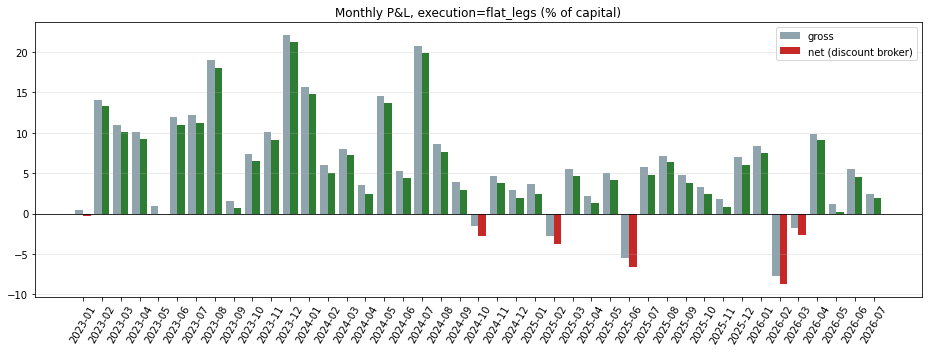

,net_pct,gross_pct
cdate,,
2023-01-31,-0.33,0.51
2023-02-28,13.31,14.06
2023-03-31,10.08,10.99
2023-04-30,9.28,10.06
2023-05-31,-0.09,0.89
2023-06-30,10.97,11.98
2023-07-31,11.27,12.24
2023-08-31,18.08,19.07
2023-09-30,0.71,1.55


In [8]:
# ── Monthly P&L (% of capital) ────────────────────────────────────────────────
monthly = daily.copy()
monthly.index = pd.to_datetime(monthly.index)
monthly_table = monthly["act_pnl_pct"].resample("M").sum().to_frame("net_pct")
monthly_table["gross_pct"] = monthly["pnl_pct"].resample("M").sum()

x = np.arange(len(monthly_table))
width = 0.4
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width / 2, monthly_table["gross_pct"].values, width, label="gross", color="#90a4ae")
net_colors = ["#2e7d32" if v >= 0 else "#c62828" for v in monthly_table["net_pct"]]
ax.bar(x + width / 2, monthly_table["net_pct"].values, width, label="net (discount broker)", color=net_colors)
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%Y-%m") for d in monthly_table.index], rotation=60)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Monthly P&L, execution={EXECUTION} (% of capital)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

monthly_table.round(2)

## Results Dashboard

The P&L / drawdown / monthly panels reflect `PARAMS["execution"]`. The ticker-wise, capital-allocation and per-trade panels are built from the tranche-level trade frame — for `delta` execution those tranches are shown hold-style, because the netted book has no exact per-trade attribution.

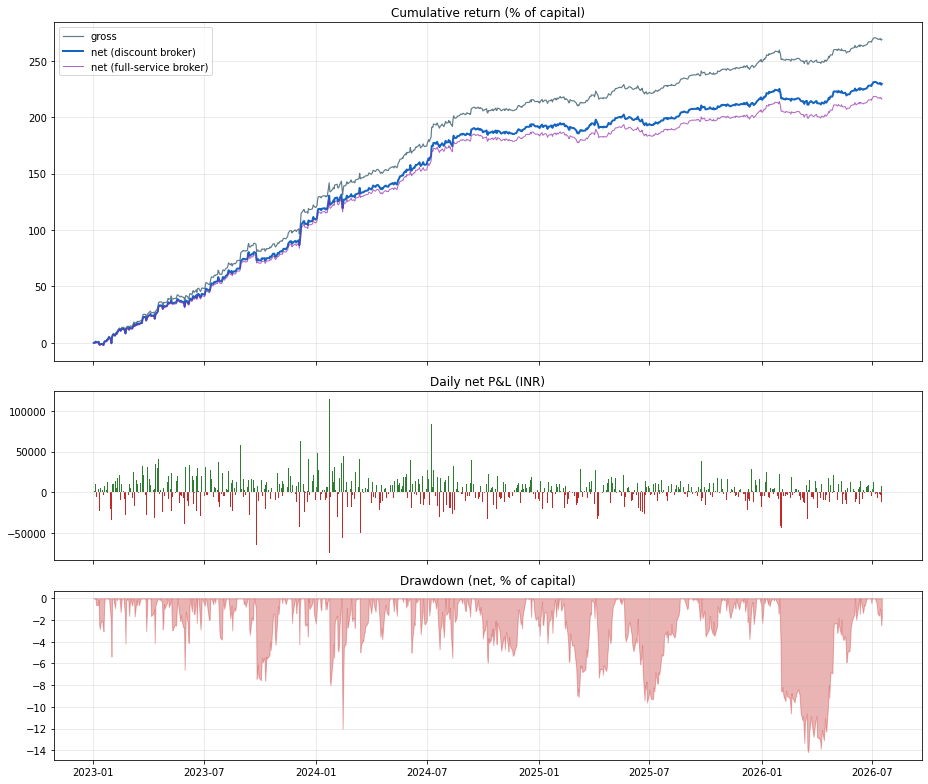

best day 114,979 | worst day -74,144 | avg day 2,624 | days 875


In [9]:
# ── Daily / cumulative P&L and drawdown ──────────────────────────────────────
idx = pd.to_datetime(pd.Series(list(daily.index)))
net_cum = daily["act_pnl_pct"].cumsum()
dd = net_cum - net_cum.cummax()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1]})
axes[0].plot(idx, daily["pnl_pct"].cumsum().values, label="gross", lw=1.2, color="#607d8b")
axes[0].plot(idx, net_cum.values, label="net (discount broker)", lw=2.0, color="#1565c0")
axes[0].plot(idx, daily["act_pnl_pct2"].cumsum().values, label="net (full-service broker)",
             lw=1.0, alpha=0.7, color="#8e24aa")
axes[0].set_title("Cumulative return (% of capital)")
axes[0].legend(); axes[0].grid(alpha=0.3)

bar_colors = ["#2e7d32" if v >= 0 else "#c62828" for v in daily["act_pnl"]]
axes[1].bar(idx, daily["act_pnl"].values, color=bar_colors, width=1.2)
axes[1].set_title("Daily net P&L (INR)"); axes[1].grid(alpha=0.3)

axes[2].fill_between(idx, dd.values, 0, color="#c62828", alpha=0.35)
axes[2].set_title("Drawdown (net, % of capital)"); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"best day {daily['act_pnl'].max():,.0f} | worst day {daily['act_pnl'].min():,.0f} | "
      f"avg day {daily['act_pnl'].mean():,.0f} | days {len(daily)}")

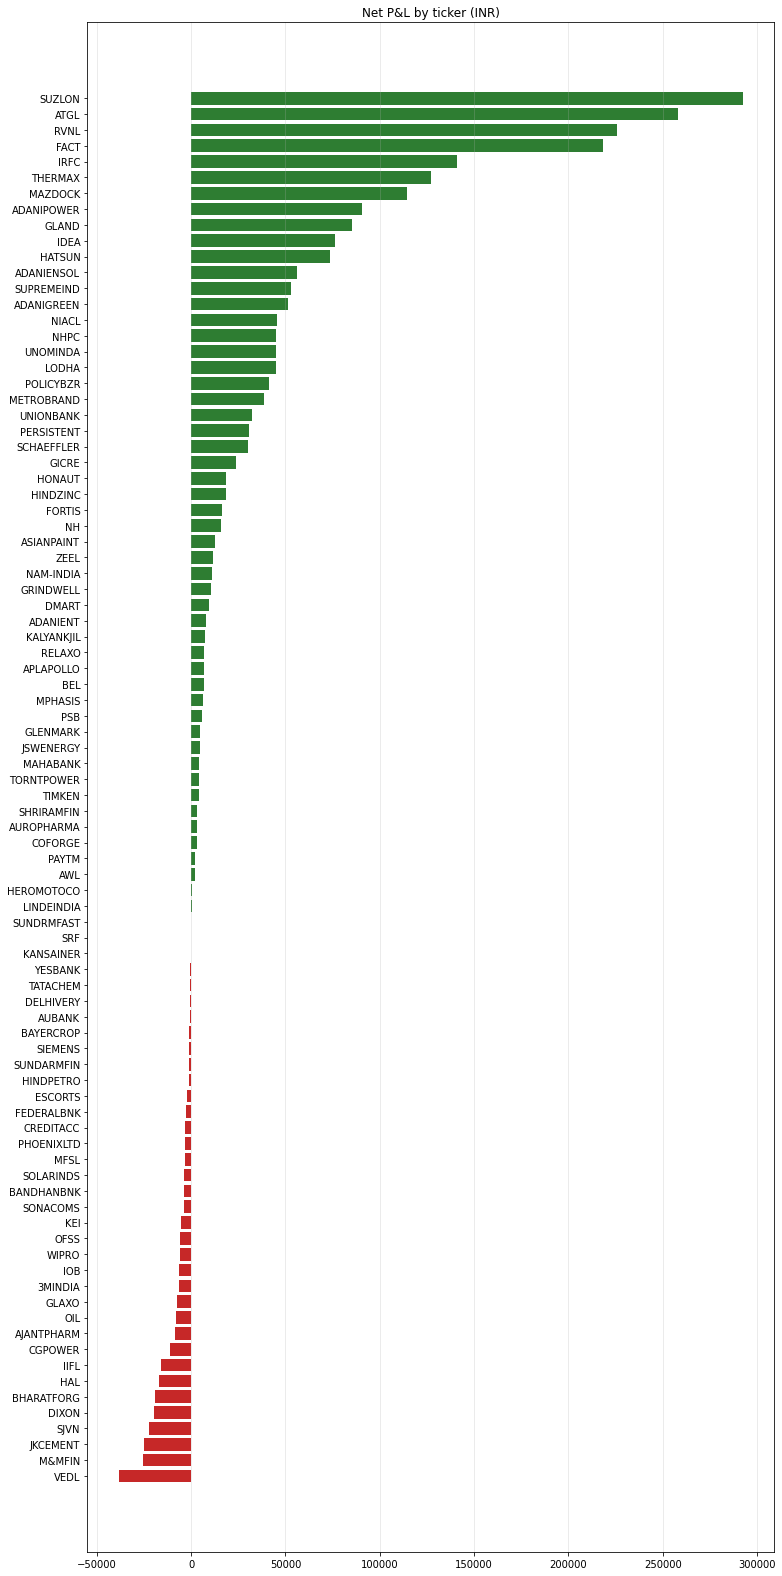

--- top 10 ---


,trades,gross,win_rate_pct,net
ticker,,,,
SUZLON,175,283046.4,53.7,292603.6
ATGL,68,245592.6,58.8,257886.9
RVNL,120,94234.8,46.7,226029.3
FACT,76,71238.6,44.7,218129.9
IRFC,57,31473.6,43.9,140803.6
THERMAX,34,80260.8,61.8,127065.6
MAZDOCK,57,134740.8,57.9,114186.5
ADANIPOWER,63,90335.0,58.7,90370.3
GLAND,58,11847.1,60.3,85538.8


--- bottom 5 ---


,trades,gross,win_rate_pct,net
ticker,,,,
DIXON,8,-19614.0,37.5,-19581.2
SJVN,3,-70740.2,0.0,-22239.6
JKCEMENT,5,8138.0,80.0,-25198.3
M&MFIN,9,-17672.7,33.3,-25306.4
VEDL,4,-33950.5,50.0,-38490.0


In [10]:
# ── Ticker-wise P&L ───────────────────────────────────────────────────────────
tk = trade_df.assign(net=trade_df["pnl"] - trade_df["intra_cost"] - trade_df["del_cost"])
net_by_ticker = tk.groupby("ticker")["net"].sum().sort_values()
deliv = tk[tk["perc"] != 0]
ticker_stats = deliv.groupby("ticker").agg(
    trades=("pnl", "count"),
    gross=("pnl", "sum"),
    win_rate_pct=("pnl", lambda s: (s > 0).mean() * 100),
)
ticker_stats["net"] = net_by_ticker
ticker_stats = ticker_stats.sort_values("net", ascending=False)

fig, ax = plt.subplots(figsize=(11, max(5, len(net_by_ticker) * 0.25)))
colors = ["#2e7d32" if v >= 0 else "#c62828" for v in net_by_ticker.values]
ax.barh(list(net_by_ticker.index), net_by_ticker.values, color=colors)
ax.set_title("Net P&L by ticker (INR)"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

print("--- top 10 ---"); display(ticker_stats.head(10).round(1))
print("--- bottom 5 ---"); display(ticker_stats.tail(5).round(1))

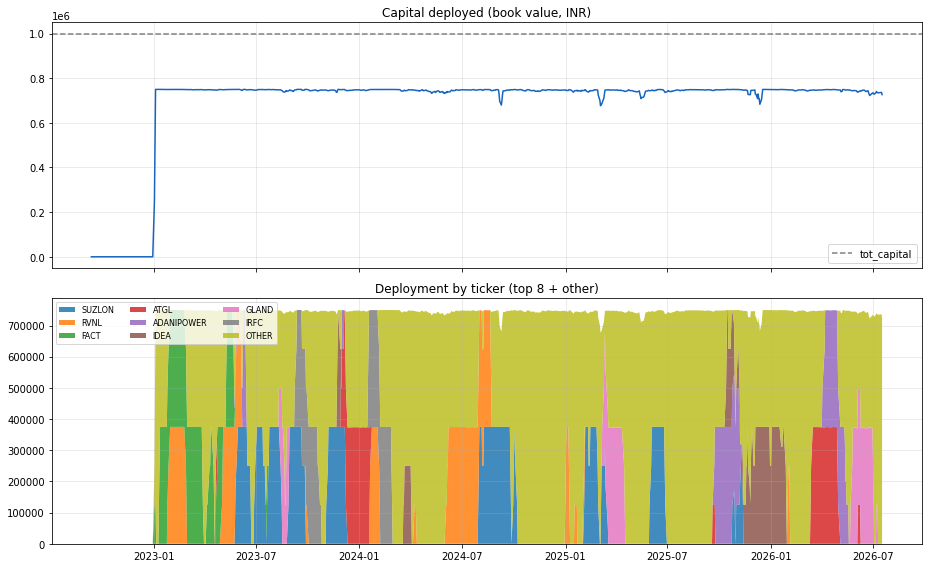

avg utilisation 68.5% | max 75.0%


In [11]:
# ── Capital allocation over time ──────────────────────────────────────────────
from intraday_research.btst_lagrangian import align_universe

opens_w, closes_w = align_universe(data, verbose=False)
dates_list = list(closes_w.index)
pos_idx = {d: i for i, d in enumerate(dates_list)}
alloc = pd.DataFrame(0.0, index=closes_w.index, columns=sorted(trade_df["ticker"].unique()))
for _, r in trade_df[trade_df["perc"] != 0].iterrows():
    start = pos_idx[r["tdate"]]
    end = pos_idx[r["cdate"]] if r["cdate"] in pos_idx else len(dates_list)
    alloc.iloc[start:end, alloc.columns.get_loc(r["ticker"])] += r["quantity"] * r["open_price"]

deployed = alloc.sum(axis=1)
idx_a = pd.to_datetime(pd.Series(dates_list))
top_cols = alloc.sum().sort_values(ascending=False).head(8).index
stack = alloc[top_cols].copy()
stack["OTHER"] = alloc.drop(columns=top_cols).sum(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(idx_a, deployed.values, lw=1.5, color="#1565c0")
axes[0].axhline(PARAMS["tot_capital"], color="gray", ls="--", label="tot_capital")
axes[0].set_title("Capital deployed (book value, INR)")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].stackplot(idx_a, [stack[c].values for c in stack.columns],
                  labels=list(stack.columns), alpha=0.85)
axes[1].set_title("Deployment by ticker (top 8 + other)")
axes[1].legend(loc="upper left", ncol=3, fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"avg utilisation {deployed.mean() / PARAMS['tot_capital'] * 100:.1f}% | "
      f"max {deployed.max() / PARAMS['tot_capital'] * 100:.1f}%")

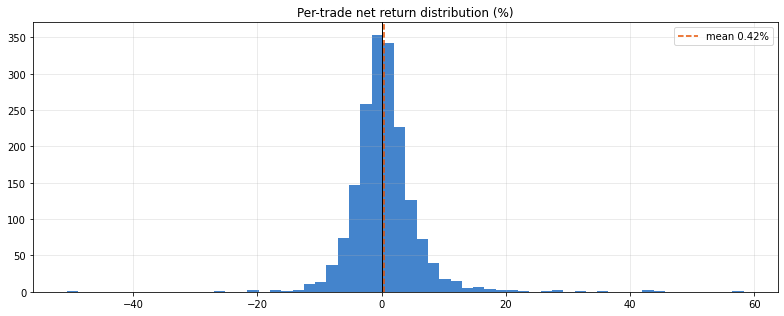

trades 1772 | win rate 51.6% | avg win 3.76% | avg loss -3.14% | gain/pain 1.28


In [12]:
# ── Per-trade return distribution (completed delivery legs) ───────────────────
completed = trade_df[(trade_df["perc"] != 0) & (trade_df["close_price"] != 0)].copy()
completed["ret_pct"] = (completed["pnl"] - completed["del_cost"]) / completed["buy_value"] * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(completed["ret_pct"], bins=60, color="#1565c0", alpha=0.8)
ax.axvline(0, color="black", lw=1)
ax.axvline(completed["ret_pct"].mean(), color="#e65100", ls="--",
           label=f"mean {completed['ret_pct'].mean():.2f}%")
ax.set_title("Per-trade net return distribution (%)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

wins = completed[completed["ret_pct"] > 0]
losses = completed[completed["ret_pct"] < 0]
print(f"trades {len(completed)} | win rate {len(wins) / len(completed) * 100:.1f}% | "
      f"avg win {wins['ret_pct'].mean():.2f}% | avg loss {losses['ret_pct'].mean():.2f}% | "
      f"gain/pain {wins['ret_pct'].sum() / abs(losses['ret_pct'].sum()):.2f}")

## Parameter Sweep

The optimiser weights depend only on `lb / frequency_type / rmean / objective / risk_free_rate` — the sweep computes one weight history per such combo (in parallel) and reuses it across every `trades / lf / execution` variant, so downstream variants are nearly free.

**Execution modes** (`params["execution"]`):
- `flat_legs` — original live behaviour: overnight-only exposure, sell-open/re-buy-close every pending day (max cost).
- `hold` — buy entry close, hold, sell exit open: delivery costs only, but intraday exposure too.
- `delta` — keep the net target book, trade only daily differences (what live consolidated orders effectively did): overlapping tranches net out, churn drops sharply.

Judge configs on **net** (discount broker) Sharpe/return — the gross column is only there to show cost drag. With ~1.5 years of data, treat small differences between configs as noise; prefer configs whose neighbours also score well.

In [13]:
# quick look: same signal, four execution styles (reuses signal_df from above)
from intraday_research.btst_lagrangian import backtest_daily_from_signals

execution_daily = {}
comparison = []
for execution in ["flat_legs", "hold", "delta", "delta_close"]:
    daily_x, metrics_x = backtest_daily_from_signals({**PARAMS, "execution": execution},
                                                     signal_df, opens_w, closes_w)
    execution_daily[execution] = daily_x
    comparison.append({
        "execution": execution,
        "gross_pct": metrics_x.loc["gross", "total_return_pct"],
        "net_pct": metrics_x.loc["net (discount broker)", "total_return_pct"],
        "net_sharpe": metrics_x.loc["net (discount broker)", "sharpe"],
        "net_maxdd_pct": metrics_x.loc["net (discount broker)", "max_drawdown_pct"],
    })
pd.DataFrame(comparison).set_index("execution").round(2)

,gross_pct,net_pct,net_sharpe,net_maxdd_pct
execution,,,,
flat_legs,269.05,229.58,2.73,-14.17
hold,117.23,97.60,1.74,-18.38
delta,64.01,55.62,0.59,-34.02
delta_close,54.64,46.26,0.46,-35.15


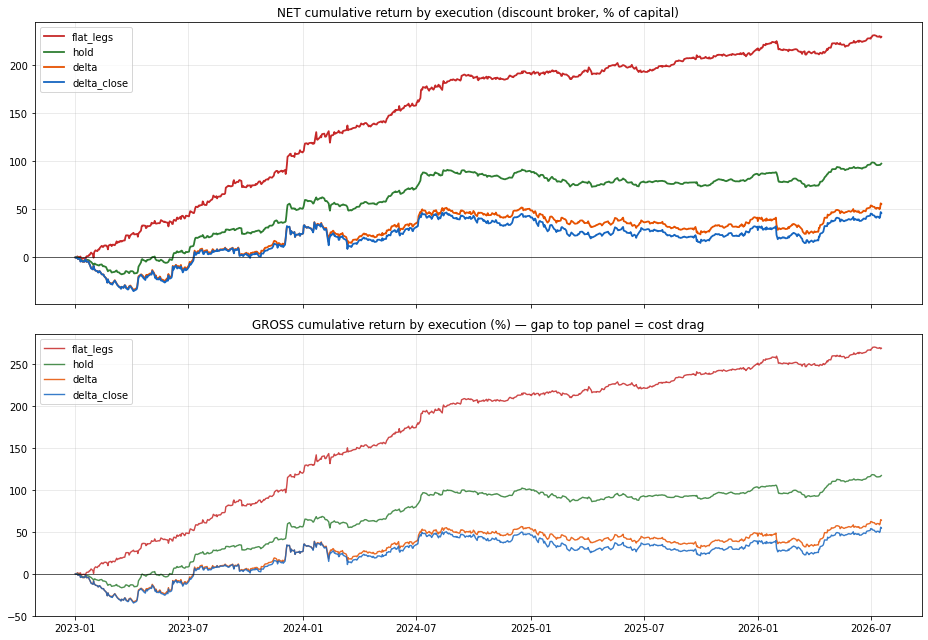

In [14]:
# ── Cumulative return of each execution style ─────────────────────────────────
# flat_legs books pnl on exit days (overnight-only exposure); hold books whole
# trades on their exit day; delta / delta_close are daily mark-to-market of the
# netted book — so the *path* differs even where totals are close.
colors = {"flat_legs": "#c62828", "hold": "#2e7d32", "delta": "#e65100", "delta_close": "#1565c0"}
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for execution, d_x in execution_daily.items():
    xs = pd.to_datetime(pd.Series(list(d_x.index)))
    axes[0].plot(xs, d_x["act_pnl_pct"].cumsum().values, label=execution,
                 lw=1.8, color=colors[execution])
    axes[1].plot(xs, d_x["pnl_pct"].cumsum().values, label=execution,
                 lw=1.4, color=colors[execution], alpha=0.85)
axes[0].set_title("NET cumulative return by execution (discount broker, % of capital)")
axes[1].set_title("GROSS cumulative return by execution (%) — gap to top panel = cost drag")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3); ax.axhline(0, color="black", lw=0.6)
plt.tight_layout(); plt.show()

In [15]:
SWEEP_GRID = {
    "lb": [20, 30],
    "trades": [5],
    "lf": [1, 2, 3, 5],
    "execution": ["flat_legs", "delta", "delta_close"], #"hold",
    # widen once the structural winners are clear (each adds weight histories):
    "objective": ["lagrangian", "sortino"] , # "min_variance", "combined"],
    "rmean": ["sma", "wma", "ewma"],
#     "l2_penalty": [0.01, 0.05, 0.2],
}

leaderboard = run_sweep(data, base_params=PARAMS, grid=SWEEP_GRID, max_workers=4)
leaderboard.sort_values(by=['gross_pct'], ascending=[False]).head(20).round(2)

Dropped tickers (incomplete history): ['IREDA', 'JIOFIN', 'JSWINFRA', 'LLOYDSME', 'MANKIND', 'TATATECH']
12 weight histories x 12 downstream variants
  weight history 1/12 done
  weight history 2/12 done
  weight history 3/12 done
  weight history 4/12 done
  weight history 5/12 done
  weight history 6/12 done
  weight history 7/12 done
  weight history 8/12 done
  weight history 9/12 done
  weight history 10/12 done
  weight history 11/12 done
  weight history 12/12 done


,lb,trades,lf,execution,objective,rmean,frequency_type,gross_pct,gross_sharpe,net_pct,net_sharpe,net_sortino,net_maxdd_pct,net_win_days_pct,net2_pct,days
3,30,5,5,flat_legs,sortino,sma,close to open,293.69,3.24,250.48,2.77,4.30,-15.08,56.69,242.09,875
7,30,5,5,flat_legs,sortino,wma,close to open,284.04,3.01,238.25,2.52,4.28,-16.71,55.43,226.17,875
15,20,5,5,flat_legs,sortino,wma,close to open,277.99,2.76,229.35,2.28,3.58,-17.08,56.46,213.41,875
8,20,5,5,flat_legs,sortino,sma,close to open,276.04,3.02,230.23,2.52,4.43,-15.46,55.54,217.51,875
4,30,5,3,flat_legs,sortino,sma,close to open,269.05,3.21,229.58,2.73,4.09,-14.17,57.83,216.76,875
6,20,5,3,flat_legs,sortino,sma,close to open,266.25,2.99,224.66,2.53,4.43,-12.37,57.60,205.79,875
14,20,5,3,flat_legs,sortino,wma,close to open,264.84,2.82,220.77,2.35,3.72,-11.77,56.34,196.15,875
11,30,5,3,flat_legs,sortino,wma,close to open,264.32,2.89,222.57,2.43,3.85,-12.37,57.14,203.64,875
21,30,5,5,flat_legs,lagrangian,ewma,close to open,261.47,2.47,206.67,1.95,3.14,-23.23,53.26,188.18,875
27,20,5,5,flat_legs,lagrangian,ewma,close to open,246.31,2.43,190.75,1.89,2.80,-21.92,54.06,171.94,875


In [16]:
leaderboard.sort_values(by=[ 'net_pct', 'net_maxdd_pct'], ascending=[False, True]).head(20)

,lb,trades,lf,execution,objective,rmean,frequency_type,gross_pct,gross_sharpe,net_pct,net_sharpe,net_sortino,net_maxdd_pct,net_win_days_pct,net2_pct,days
3,30,5,5,flat_legs,sortino,sma,close to open,293.686894,3.244092,250.476159,2.766281,4.300374,-15.078088,56.685714,242.092541,875
7,30,5,5,flat_legs,sortino,wma,close to open,284.041775,3.010231,238.249854,2.524174,4.280574,-16.712100,55.428571,226.170727,875
8,20,5,5,flat_legs,sortino,sma,close to open,276.037581,3.017890,230.227915,2.516570,4.434676,-15.455736,55.542857,217.509897,875
4,30,5,3,flat_legs,sortino,sma,close to open,269.053622,3.205354,229.576792,2.734670,4.086691,-14.168553,57.828571,216.755619,875
15,20,5,5,flat_legs,sortino,wma,close to open,277.994940,2.758842,229.354859,2.275895,3.578106,-17.078215,56.457143,213.411520,875
6,20,5,3,flat_legs,sortino,sma,close to open,266.246488,2.994167,224.658705,2.525837,4.434445,-12.369879,57.600000,205.787513,875
11,30,5,3,flat_legs,sortino,wma,close to open,264.316988,2.885507,222.567767,2.428957,3.854426,-12.368479,57.142857,203.639783,875
14,20,5,3,flat_legs,sortino,wma,close to open,264.837225,2.820782,220.767043,2.351151,3.723350,-11.770161,56.342857,196.149725,875
21,30,5,5,flat_legs,lagrangian,ewma,close to open,261.474051,2.472390,206.668949,1.954849,3.135803,-23.230761,53.257143,188.176631,875
9,20,5,2,flat_legs,sortino,sma,close to open,238.845317,2.967727,200.885253,2.495085,3.685999,-11.274676,57.714286,178.547850,875


In [ ]:
# equity curves of the top-3 configs (re-runs their weight histories)
fig, ax = plt.subplots(figsize=(12, 5))
for _, cfg in leaderboard.head(3).iterrows():
    p = {**PARAMS, "lb": int(cfg["lb"]), "trades": int(cfg["trades"]),
         "lf": int(cfg["lf"]), "execution": cfg["execution"]}
    d_top, _ = backtest_daily(p, data, verbose=False)
    label = f"lb={cfg['lb']} trades={cfg['trades']} lf={cfg['lf']} {cfg['execution']}"
    d_top["act_pnl_pct"].cumsum().plot(ax=ax, label=label)
daily["act_pnl_pct"].cumsum().plot(ax=ax, label="base config (flat_legs)", linestyle="--", color="gray")
ax.set_title("Top sweep configs — cumulative net return (% of capital)")
ax.set_ylabel("%")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Market Regime Filter (weekly NIFTY SMMA5 ± ATR14)

A global ON/OFF filter above the strategy. From completed weekly NIFTY candles: **OFF** when weekly close < SMMA5 − 0.25·ATR14 (block new tranches, existing exits continue), **force-exit everything** after 2 consecutive closes below the band (confirmed mode) or on a close below the previous 10-week low (emergency). **ON** again only when weekly close > SMMA5 + 0.10·ATR14. Between the bands the state is retained (hysteresis). Signals act from the **next trading session**, never the close that generated them.

Versions compared (spec): **A** no filter · **B** SMMA-only · **C** symmetric ±0.25 ATR · **D** asymmetric −0.25/+0.10 confirmed (recommended) · **E** asymmetric immediate · **F** = D without emergency exit.

In [ ]:
# ── Build the weekly filter (needs NIFTY daily history incl. ~100-week warm-up)
from intraday_research.market_regime import (
    RegimeConfig, build_weekly_filter, regime_event_log, daily_state_frame,
    apply_regime_to_signals, compare_regime_versions, off_period_report,
)

REGIME_WARMUP_START = "2022-07-01"
NIFTY_SYMBOL = "NSE:NIFTY50-INDEX"
REGIME_CONFIG = RegimeConfig(exit_atr_multiplier=0.50, reentry_atr_multiplier=0.15,smma_period=5)   # version D defaults

nifty_cache = CACHE_DATA_DIR / f"{safe_symbol_filename(NIFTY_SYMBOL)}.parquet"
if FETCH_MISSING_SPOT_DATA:
    command = [
        sys.executable, str(REPO_ROOT / "scripts" / "fetch_fyers_intraday_data.py"),
        "--auth-file", str(AUTH_FILE), "--user-key", USER_KEY,
        "--start", REGIME_WARMUP_START, "--end", END_DATE,
        "--output-dir", str(CACHE_DATA_DIR), "--format", "parquet",
        "--resolution", "D", "--chunk-days", "365",
        "--symbol", NIFTY_SYMBOL,
    ]
    result = subprocess.run(command, cwd=REPO_ROOT, text=True, capture_output=True)
    if result.returncode != 0:
        print(result.stderr[-1500:])
        print("WARNING: NIFTY fetch failed - using cached range only")

nifty_daily = pd.read_parquet(nifty_cache)
nifty_daily["timestamp"] = pd.to_datetime(nifty_daily["timestamp"])
nifty_daily["Date"] = nifty_daily["timestamp"].dt.date
nifty_daily = nifty_daily.rename(columns={"open": "Open", "high": "High",
                                          "low": "Low", "close": "Close"})
nifty_daily = nifty_daily[["Date", "Open", "High", "Low", "Close"]].sort_values("Date").reset_index(drop=True)
print(f"NIFTY daily: {nifty_daily['Date'].min()} -> {nifty_daily['Date'].max()} ({len(nifty_daily)} sessions)")

weekly_filter = build_weekly_filter(nifty_daily, REGIME_CONFIG)
weekly_filter.to_csv(REPO_ROOT / "notebooks" / "nifty_weekly_market_filter.csv", index=False)
events = regime_event_log(weekly_filter)
events.to_csv(REPO_ROOT / "notebooks" / "market_filter_events.csv", index=False)
print(f"completed weeks: {len(weekly_filter)} | OFF weeks: {(weekly_filter['market_state'] == 'OFF').sum()} "
      f"| transitions: {(weekly_filter['transition'] != 'NONE').sum()}")
events[["week_end_date", "effective_from_date", "transition", "reason", "weekly_close",
        "lower_band", "upper_band", "force_exit_all"]].tail(12).round(1)

In [ ]:
# ── NIFTY weekly close vs bands with ON/OFF shading ──────────────────────────
wf_plot = weekly_filter[weekly_filter["week_end_date"] >= pd.Timestamp(START_DATE).date()].reset_index(drop=True)
x = pd.to_datetime(pd.Series(list(wf_plot["week_end_date"])))

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(x, wf_plot["weekly_close"].values, label="NIFTY weekly close", lw=1.8, color="#1565c0")
ax.plot(x, wf_plot["smma_5"].values, label="SMMA5", lw=1.2, color="#e65100")
ax.plot(x, wf_plot["lower_band"].values, ls="--", lw=1.0, color="#c62828", label="lower band (risk-off)")
ax.plot(x, wf_plot["upper_band"].values, ls="--", lw=1.0, color="#2e7d32", label="upper band (re-entry)")
ylim = ax.get_ylim()
ax.fill_between(x, ylim[0], ylim[1], where=(wf_plot["market_state"] == "OFF").values,
                color="#c62828", alpha=0.10, label="OFF")
for _, ev in wf_plot[wf_plot["transition"] == "ON_TO_OFF"].iterrows():
    ax.plot(pd.Timestamp(ev["week_end_date"]), ev["weekly_close"], "v", color="#c62828", ms=10)
for _, ev in wf_plot[wf_plot["transition"] == "OFF_TO_ON"].iterrows():
    ax.plot(pd.Timestamp(ev["week_end_date"]), ev["weekly_close"], "^", color="#2e7d32", ms=10)
for _, ev in wf_plot[wf_plot["force_exit_all"]].iterrows():
    ax.plot(pd.Timestamp(ev["week_end_date"]), ev["weekly_close"], "x", color="black", ms=11, mew=2.5)
ax.set_ylim(ylim)
ax.set_title("NIFTY weekly regime filter — v ON→OFF, ^ OFF→ON, x force-exit")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ── Versions A-F comparison (reuses the signals computed above) ───────────────
regime_summary, regime_details = compare_regime_versions(
    PARAMS, data, nifty_daily, verbose=False, signal_df=signal_df)
display(regime_summary.round(2))

off_report = off_period_report(regime_details["D_asym_confirmed"][2], nifty_daily,
                               regime_details["D_asym_confirmed"][0])
off_report.to_csv(REPO_ROOT / "notebooks" / "market_filter_off_periods.csv", index=False)
print("--- OFF periods under version D ---")
off_report.round(2)

### Test your own filter configs (weekly or daily)

Edit `my_versions` below and re-run this cell — the charts underneath update automatically. Every `RegimeConfig` field is tunable, and `timeframe="daily"` runs the identical band state machine on **daily** NIFTY candles (signal from the daily close, effective next session). On daily, all periods are in **days** — as a rough weekly→daily translation: SMMA 5w ≈ 25d, band multipliers ÷ √5 (weekly ATR ≈ 2.2× daily ATR), confirmation 2w ≈ 10d, emergency lookback 10w ≈ 50d.

Caution: the sample has only ~10 OFF periods — keep changes coarse and prefer configs whose neighbours also score well; don't tune band multipliers to one crash.

`filter_style="band_momentum"` is the direction-aware 3-state machine (ON / WARN / DOWN): buying stops when the close falls below the **upper** band from above, everything is sold the moment the **lower** band breaks (no confirmation wait), and buying resumes as soon as the close reclaims the lower band from below. Reversals between the bands are not events. Works with `timeframe="daily"` too.


In [ ]:
# ── EDIT ME: custom regime configs ────────────────────────────────────────────
my_versions = {
    "A_original":        None,                                  # no-filter baseline
    "D_weekly_default":  RegimeConfig(),
    "weekly_wide_exit":  RegimeConfig(exit_atr_multiplier=0.55, reentry_atr_multiplier=0.15,smma_period=5),
    "weekly_confirm_3":  RegimeConfig(confirmation_weeks=3),
    "daily_25_default":  RegimeConfig(timeframe="daily", smma_period=5, atr_period=14,
                                      exit_atr_multiplier=0.50, reentry_atr_multiplier=0.22,
                                      confirmation_weeks=1, emergency_low_lookback=10),
    "daily_20_fast":     RegimeConfig(timeframe="daily", smma_period=20, atr_period=14,
                                      exit_atr_multiplier=0.40, reentry_atr_multiplier=0.15,
                                      confirmation_weeks=5, emergency_low_lookback=50),
    "daily_5_fast":     RegimeConfig(timeframe="daily", smma_period=5, atr_period=14,
                                      exit_atr_multiplier=1, reentry_atr_multiplier=0.50,
                                      confirmation_weeks=5, emergency_low_lookback=10),
    # band_momentum: stop buying when close falls below the UPPER band from
    # above (early warning), SELL ALL the moment the LOWER band breaks (no
    # confirmation wait), resume buying once close reclaims the LOWER band.
    "bm_default":        RegimeConfig(filter_style="band_momentum"),
    "bm_symmetric":      RegimeConfig(filter_style="band_momentum",
                                      exit_atr_multiplier=0.25, reentry_atr_multiplier=0.25),
    "bm_wide":           RegimeConfig(filter_style="band_momentum",
                                      exit_atr_multiplier=0.50, reentry_atr_multiplier=0.25),
    "bm_wide_v1":           RegimeConfig(filter_style="band_momentum",
                                      exit_atr_multiplier=0.50, reentry_atr_multiplier=0.50),
    # sma_weekly_daily: plain 5-week SIMPLE MA, no bands/hysteresis. Weekly
    # close < SMA -> sell all + block until a weekly close > SMA. PLUS a daily
    # overlay: any day NIFTY trades below the LAST completed week's SMA ->
    # no new buys and force-exit the book that day (delta_close-aligned).
    "sma5_weekly_daily": RegimeConfig(filter_style="sma_weekly_daily", smma_period=5),
}

regime_summary, regime_details = compare_regime_versions(
    PARAMS, data, nifty_daily, versions=my_versions, verbose=False, signal_df=signal_df)
regime_summary.round(2)

In [ ]:
# ── Equity curves for the versions above, drawdown baseline vs best ──────────
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
baseline = "A_original" if "A_original" in regime_summary.index else regime_summary.index[0]
best = regime_summary.drop(index=baseline, errors="ignore")["net_sharpe"].idxmax()

for name, (d_v, _m, _w) in regime_details.items():
    cum = d_v["act_pnl_pct"].cumsum()
    xs = pd.to_datetime(pd.Series(list(d_v.index)))
    emphasized = name in (baseline, best)
    axes[0].plot(xs, cum.values, label=name, lw=2.2 if emphasized else 1.0,
                 alpha=1.0 if emphasized else 0.65)
axes[0].set_title(f"Cumulative net return by filter version, execution={PARAMS.get('execution', 'flat_legs')} (%)")
axes[0].legend(); axes[0].grid(alpha=0.3)

for name, color in [(baseline, "#607d8b"), (best, "#1565c0")]:
    d_v = regime_details[name][0]
    cum = d_v["act_pnl_pct"].cumsum()
    dd = cum - cum.cummax()
    xs = pd.to_datetime(pd.Series(list(d_v.index)))
    axes[1].fill_between(xs, dd.values, 0, alpha=0.35, color=color, label=name)
axes[1].set_title(f"Drawdown: {baseline} vs {best} (best net sharpe) (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Live Signals (go-live again)

Generates today's BTST orders exactly like `nse_order_creation.py` did: last `lb` close→open returns → optimiser → top `trades` weights → buy at close with `perc · tot_capital / (lf+1)`.

For a real live run:
1. Run this just after `ENTRY_PRICE_TIME` (e.g. 15:21 IST) with `END_DATE` = today so today's minute bars up to that time are in the data. If today was already marked fetched, delete the day's coverage from the `.meta.json` files or refetch.
2. `buy_price` below uses the last close in the data — in live you'd overwrite it with the 15:24 LTP (pass an `ltp={ticker: price}` dict).
3. Each position is sold at the next open and the pending book re-bought at close daily until `lf` nights have passed (the old system's consolidated orders did this netting automatically).

In [ ]:
orders = generate_live_signals(PARAMS, data)
orders["capital"] = orders["capital"].round(0)
print(f"signal date: {orders['tdate'].iloc[0]}  |  capital tranche: {PARAMS['tot_capital'] / (PARAMS['lf'] + 1):,.0f}")
orders